# F1 AI Strategy Simulator

## Step 3 — Lap Time Prediction Model

In this notebook we train the machine learning model that predicts lap times.

This model becomes the **core engine of the race simulator**.

The model learns relationships between:

- driver skill
- car performance
- tire degradation
- fuel load
- race traffic
- track conditions

Instead of predicting raw lap time directly, the model predicts **lap time delta relative to track baseline**.

This improves accuracy because it removes track-specific speed differences.

The trained model will later be used inside the **race simulation engine**.

In [15]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

## Load Feature Dataset

We load the dataset created during Step 2.

In [16]:
df = pd.read_csv("../data/feature_dataset.csv")

print("Rows:", len(df))
df.head()

Rows: 145913


,DriverEncoded,TeamEncoded,TrackEncoded,Season,RegulationEra,LapNumber,lap_progress,Position,CompoundEncoded,tyre_age,...,WindSpeed,race_time,gap_ahead,gap_behind,traffic_pressure,drs_available,driver_pace_baseline,track_pace_baseline,pace_relative,LapTimeSeconds
0,6,9,0,2019,0,4.0,0.072727,1.0,1.0,7.0,...,2.553435,403.528,NaN,-1.595,NaN,0,100.640170,102.618405,0.148830,100.789
1,36,13,0,2019,0,4.0,0.072727,2.0,1.0,7.0,...,2.553435,405.123,1.595,-1.638,3.233,0,100.696642,102.618405,0.314358,101.011
2,15,9,0,2019,0,4.0,0.072727,3.0,1.0,7.0,...,2.553435,406.761,1.638,-3.923,5.561,0,100.665093,102.618405,0.565907,101.231
3,21,5,0,2019,0,4.0,0.072727,4.0,1.0,7.0,...,2.553435,410.684,3.923,-3.779,7.702,0,101.548231,102.618405,-0.044231,101.504
4,25,8,0,2019,0,4.0,0.072727,5.0,0.0,7.0,...,2.553435,414.463,3.779,-0.871,4.650,0,102.327385,102.618405,-0.016385,102.311


# Create Lap Time Delta Target

Instead of predicting raw lap time, we predict:

lap_time_delta = LapTimeSeconds − track_pace_baseline

In [17]:
df["lap_time_delta"] = (
    df["LapTimeSeconds"] - df["track_pace_baseline"]
)

## Define Feature Matrix

We separate the machine learning inputs (features) and the prediction target.

In [20]:
features = [
"DriverEncoded",
"TeamEncoded",
"TrackEncoded",
"Season",
"RegulationEra",
"LapNumber",
"lap_progress",
"Position",
"CompoundEncoded",
"tyre_age",
"stint_number",
"pace_trend",
"laps_since_pit",
"fuel_load",
"track_evolution",
"AirTemp",
"TrackTemp",
"Humidity",
"WindSpeed",
"gap_ahead",
"gap_behind",
"traffic_pressure",
"drs_available",
"driver_pace_baseline",
"track_pace_baseline",
"pace_relative"
]

X = df[features]

y = df["lap_time_delta"]

## Train / Test Split

We split the dataset so we can evaluate model performance on unseen data.

In [21]:
train_df = df[df["Season"] <= 2023]
test_df = df[df["Season"] >= 2024]

X_train = train_df[features]
y_train = train_df["lap_time_delta"]

X_test = test_df[features]
y_test = test_df["lap_time_delta"]

## Train XGBoost Lap Time Model

XGBoost works very well for tabular datasets and nonlinear relationships.

In [22]:
model = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


# Predict Lap Time Delta

In [23]:
delta_predictions = model.predict(X_test)

# Convert Predictions Back to Real Lap Time

In [24]:
pred_laptime = delta_predictions + test_df["track_pace_baseline"]
true_laptime = y_test + test_df["track_pace_baseline"]

## Evaluate Model Performance

We evaluate the model using Mean Absolute Error (MAE).

MAE tells us the average prediction error in seconds.

In [25]:
mae = mean_absolute_error(true_laptime, pred_laptime)

print("Lap Time Prediction MAE:", mae)

Lap Time Prediction MAE: 0.35830139180298987


## Inspect Feature Importance

This shows which race features influence lap time the most.

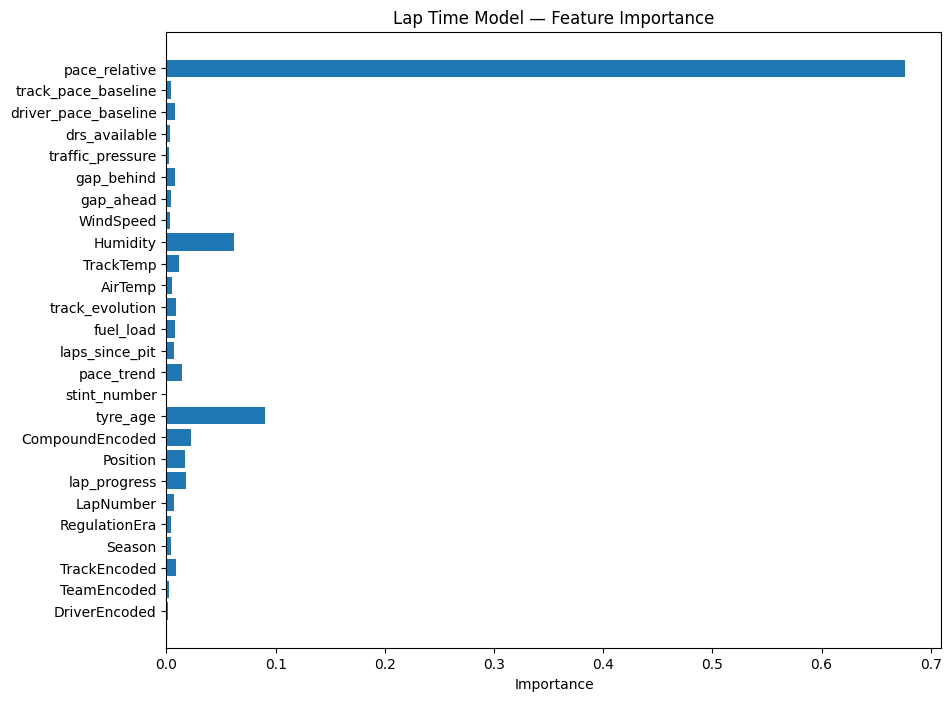

In [26]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(10,8))

plt.barh(feature_names, importance)

plt.title("Lap Time Model — Feature Importance")

plt.xlabel("Importance")

plt.show()

## Save Model

We save the trained model so the race simulator can load it later.

In [27]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/lap_time_model.pkl")

print("Lap time model saved successfully.")

Lap time model saved successfully.
